#**Decision Tree for Classification**

##Iris Plant Dataset

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


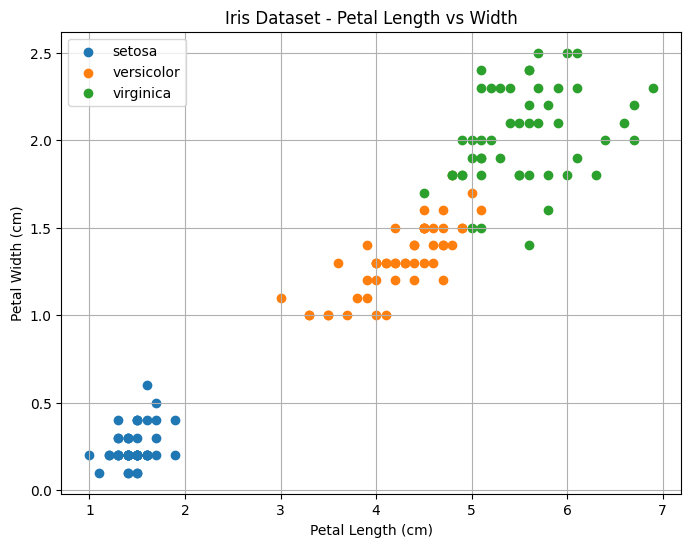

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt

# Load iris dataset
iris = load_iris()
print(iris.keys())
X = iris.data[:, 2:] # petal length and width
y = iris.target
target_names = iris.target_names

# Plot
plt.figure(figsize=(8, 6))
for i, label in enumerate(target_names):
    plt.scatter(X[y == i, 0], X[y == i, 1], label=label)

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Iris Dataset - Petal Length vs Width")
plt.legend()
plt.grid(True)
plt.show()

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



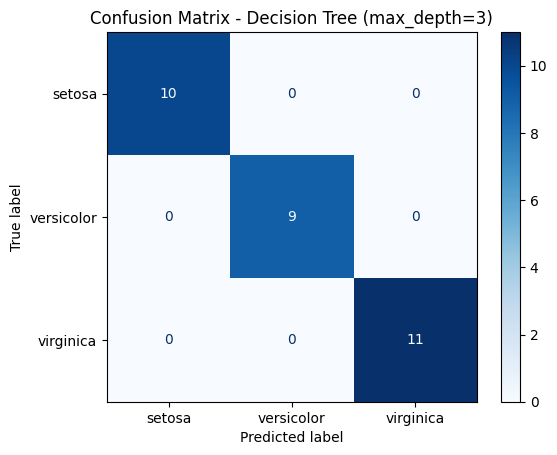

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score,confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Decision Tree
max_depth = 3
dt = DecisionTreeClassifier(max_depth=max_depth, criterion="gini")
dt.fit(X_train, y_train)

# Predict
dt.predict(X_test)
y_pred = dt.predict(X_test)
print(classification_report(y_test, y_pred))

# Predict and evaluate
y_pred_dt = dt.predict(X_test)
acc = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", acc)
print(classification_report(y_test, y_pred_dt))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)

# Display the matrix
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix - Decision Tree (max_depth={max_depth})")
plt.show()

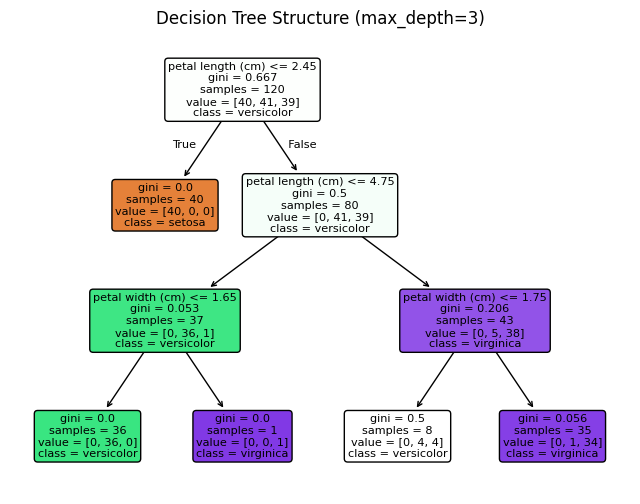

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Plot the decision tree
plt.figure(figsize=(8, 6))
plot_tree(dt,
  feature_names=iris.feature_names[2:],  # Petal length & width
  class_names=iris.target_names,
  filled=True,
  rounded=True)
plt.title("Decision Tree Structure (max_depth=3)")
plt.show()

# petal length (cm) <= 2.45  ---- decision rule (split condition)
# gini = 0.667          ---- impurity of this node (0 = pure, 1 = max impurity)
# samples = 120          ---- number of training samples that reached this node
# value = [40, 41, 39]     ---- counts of samples from each class [setosa, versicolor, virginica]
# class = setosa         ---- predicted class (the majority among the values)

# if criterion = entropy:
# entropy = 1.585        ---- Information gain measure

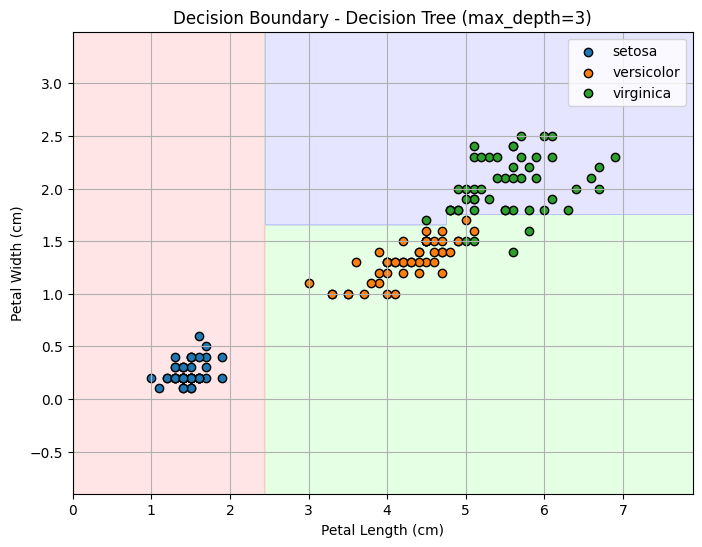

In [ ]:
from matplotlib.colors import ListedColormap
import numpy as np

# Create meshgrid based on feature ranges
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))
# Predict on the meshgrid
Z = dt.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Define color maps
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

# Plot decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)

# Plot training data
for i, label in enumerate(iris.target_names):
    plt.scatter(X[y == i, 0], X[y == i, 1], label=label, edgecolor='k')

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title(f"Decision Boundary - Decision Tree (max_depth={max_depth})")
plt.legend()
plt.grid(True)
plt.show()

##Moons Dataset

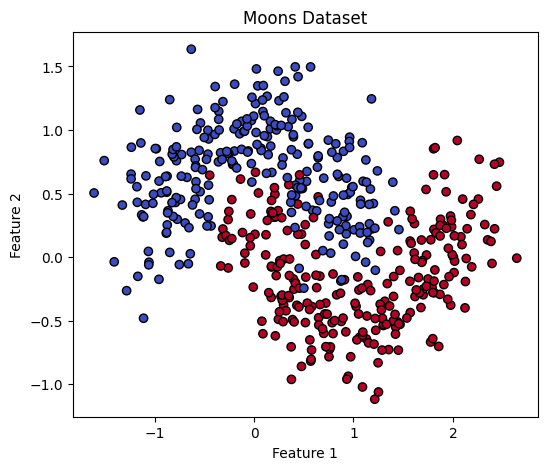

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Generate moons dataset
X, y = make_moons(n_samples=500, noise=0.25, random_state=42)

# Visualize dataset
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolor="k")
plt.title("Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


Depth of the tree: 7


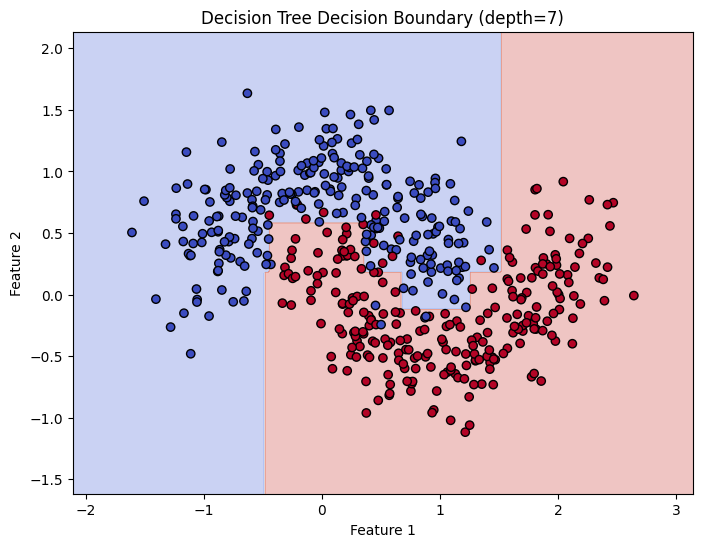

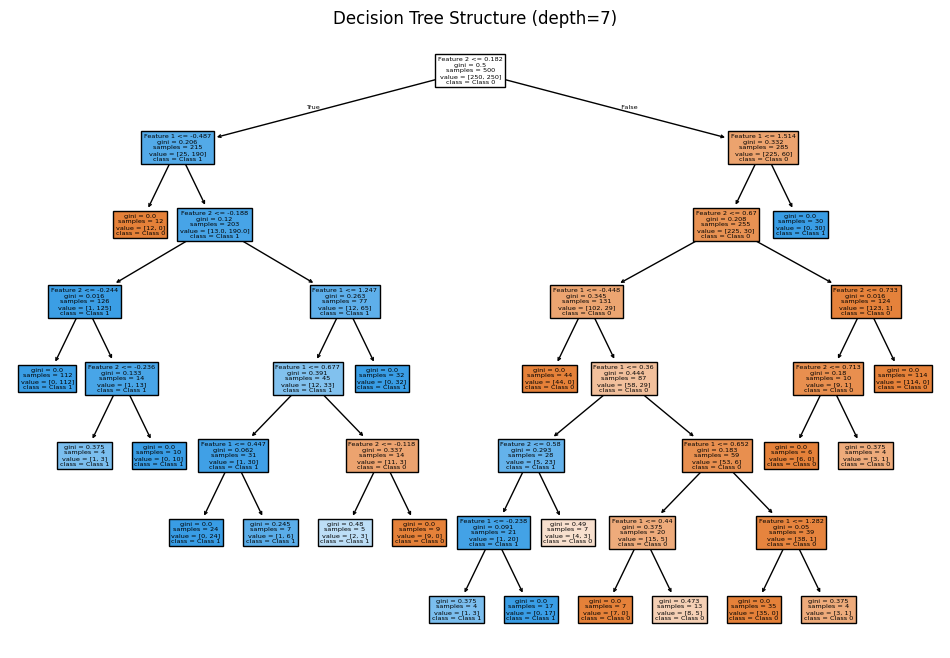

In [ ]:
# Train a Decision Tree Classifier
# when max_depth = None, it will easily overfit
# setting a smaller max_depth, tune min_sample_split, min_sample_leaf can avoid overfitting
tree_clf = DecisionTreeClassifier(max_depth=7, min_samples_split=10,min_samples_leaf=4, random_state=42)
tree_clf.fit(X, y)

# actual depth of the tree
depth = tree_clf.get_depth()
print(f"Depth of the tree: {depth}")

# Create meshgrid for decision boundary
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# Predict classes for meshgrid points
Z = tree_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", cmap=plt.cm.coolwarm)
plt.title(f"Decision Tree Decision Boundary (depth={depth})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Plot decision tree structure
plt.figure(figsize=(12, 8))
plot_tree(tree_clf, filled=True, feature_names=["Feature 1", "Feature 2"], class_names=["Class 0", "Class 1"])
plt.title(f"Decision Tree Structure (depth={depth})")
plt.show()


#**Random Forest**

##Data Visualization

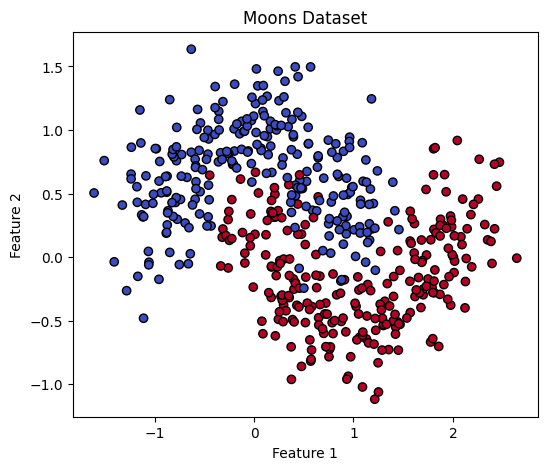

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Generate moons dataset
X, y = make_moons(n_samples=500, noise=0.25, random_state=42)

# Visualize dataset
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolor="k")
plt.title("Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

##Random Forest vs Decision Tree

Time spent for random forest: 1.04 seconds


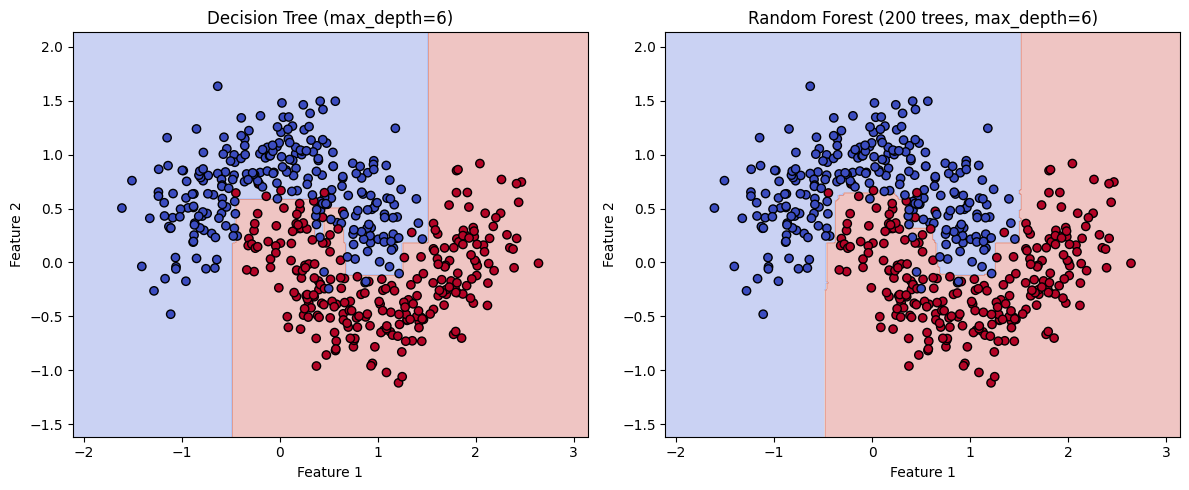

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import time
# Decision Tree (depth=6)
dt_clf = DecisionTreeClassifier(max_depth = None, max_features = None, min_samples_split = 10, min_samples_leaf=4, random_state=42)
dt_clf.fit(X, y)

# Random Forest (depth=6, 200 trees)
rf_clf = RandomForestClassifier(n_estimators=200,max_features = None, max_depth = None,min_samples_split = 10, min_samples_leaf=4, random_state=42)
start = time.time() # record the start time before training
rf_clf.fit(X, y)
end = time.time()  # record the end time after training
print(f"Time spent for random forest: {end - start:.2f} seconds")

# Create a mesh grid for decision boundary
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
# Predictions for both classifiers
Z_dt = dt_clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
Z_rf = rf_clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Plot side by side
plt.figure(figsize=(12, 5))

# Decision Tree plot
plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z_dt, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolor="k")
plt.title("Decision Tree (max_depth=6)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# Random Forest plot
plt.subplot(1, 2, 2)
plt.contourf(xx, yy, Z_rf, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolor="k")
plt.title("Random Forest (200 trees, max_depth=6)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.tight_layout()
plt.show()


## Feature Importance Ranking

Feature ranking:
1. Feature 2 (0.5598)
2. Feature 1 (0.4402)


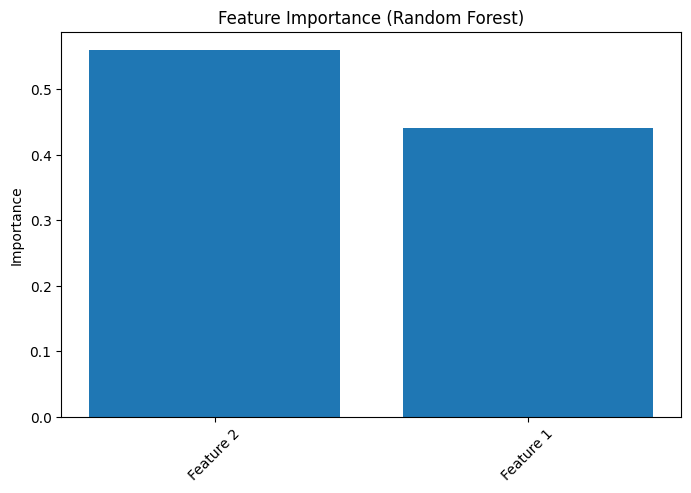

In [ ]:
# Get feature importances
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]  # sort in descending order

# Assign feature names
feature_names = ["Feature 1", "Feature 2"]

# Print ranking
print("Feature ranking:")
for i in range(len(feature_names)):
    print(f"{i+1}. {feature_names[indices[i]]} ({importances[indices[i]]:.4f})")

# Plot feature importances
plt.figure(figsize=(8, 5))
plt.bar(range(len(feature_names)), importances[indices], align="center")
plt.xticks(range(len(feature_names)), np.array(feature_names)[indices], rotation=45)
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance")
plt.show()

Feature ranking:
1. petal length (cm) (0.4593)
2. petal width (cm) (0.4179)
3. sepal length (cm) (0.1020)
4. sepal width (cm) (0.0209)


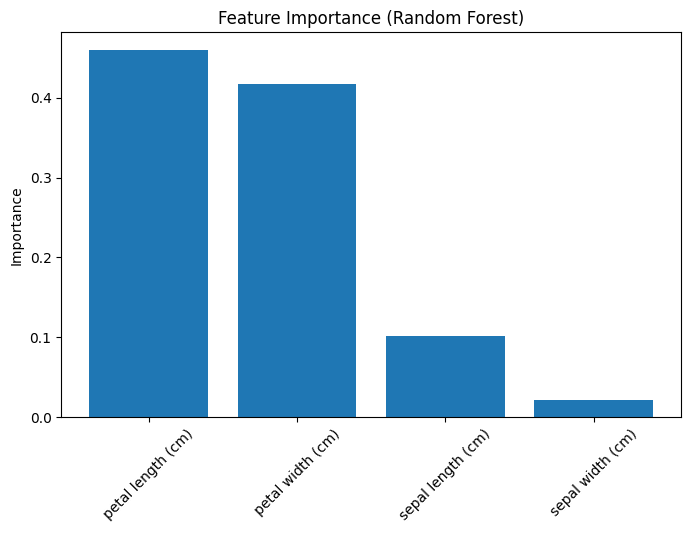

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier

# Load iris dataset
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
feature_names = iris.feature_names

# Train Random Forest
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_clf.fit(X_iris, y_iris)

# Get feature importances
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]  # sort in descending order

# Print ranking
print("Feature ranking:")
for i in range(len(feature_names)):
    print(f"{i+1}. {feature_names[indices[i]]} ({importances[indices[i]]:.4f})")

# Plot feature importances
plt.figure(figsize=(8, 5))
plt.bar(range(len(feature_names)), importances[indices], align="center")
plt.xticks(range(len(feature_names)), np.array(feature_names)[indices], rotation=45)
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance")
plt.show()

##Bagging Classifier

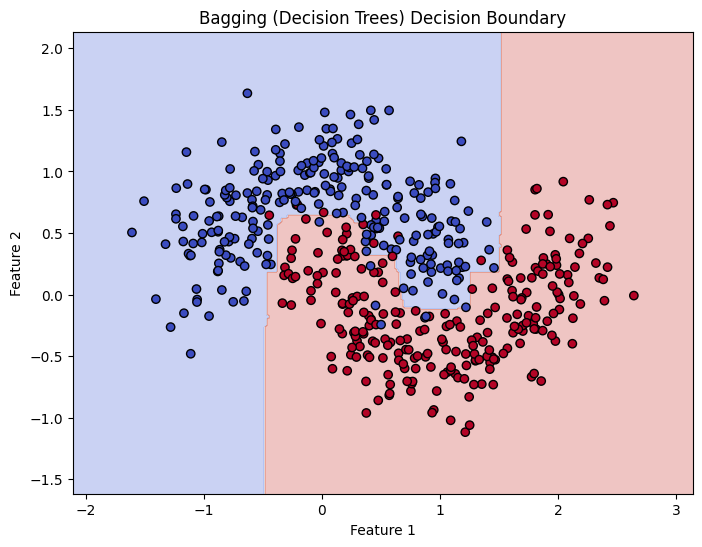

Feature ranking (Bagging with Decision Trees):
1. Feature 2 (0.5598)
2. Feature 1 (0.4402)


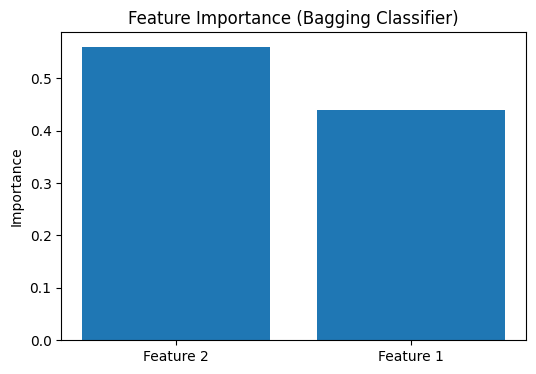

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# Generate moons dataset
X, y = make_moons(n_samples=500, noise=0.25, random_state=42)

# Base Decision Tree
dt = DecisionTreeClassifier(
    max_depth=None,        # let trees grow fully
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42
)

# Bagging with Decision Trees (500 trees)
bagging_clf = BaggingClassifier(
    estimator=dt,
    n_estimators=200,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

bagging_clf.fit(X, y)

# ---- Create mesh grid for plotting ----
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# Predictions for Bagging
Z_bagging = bagging_clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# ---- Plot Bagging decision boundary ----
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z_bagging, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolor="k")
plt.title("Bagging (Decision Trees) Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# ---- Collect and plot feature importances ----
importances = np.mean([tree.feature_importances_ for tree in bagging_clf.estimators_], axis=0)
feature_names = ["Feature 1", "Feature 2"]
indices = np.argsort(importances)[::-1]

# Print ranking
print("Feature ranking (Bagging with Decision Trees):")
for i in range(len(feature_names)):
    print(f"{i+1}. {feature_names[indices[i]]} ({importances[indices[i]]:.4f})")

# Plot feature importances
plt.figure(figsize=(6, 4))
plt.bar(range(len(feature_names)), importances[indices], align="center")
plt.xticks(range(len(feature_names)), np.array(feature_names)[indices])
plt.title("Feature Importance (Bagging Classifier)")
plt.ylabel("Importance")
plt.show()


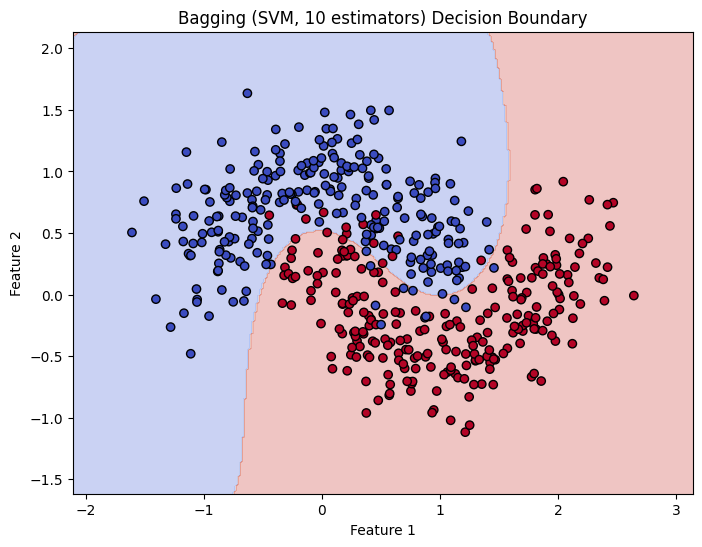

In [ ]:
from sklearn.svm import SVC

# ---- Bagging with SVM ----
svm_clf = SVC(kernel="rbf", C=1.0, probability=True, random_state=42)

num_estimators = 10
bagging_svm = BaggingClassifier(
    estimator=svm_clf,
    n_estimators=num_estimators,       # number of SVM models
    max_samples=0.8,       # each SVM sees 80% of training samples
    bootstrap=True,        # bagging (with replacement)
    n_jobs=-1,
    random_state=42
)
bagging_svm.fit(X, y)

# ---- Create mesh grid for plotting ----
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# Predictions
Z_bagging_svm = bagging_svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# ---- Plot Bagging+SVM decision boundary ----
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z_bagging_svm, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolor="k")
plt.title(f"Bagging (SVM, {num_estimators} estimators) Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

#**XGBoost**
XGBoost (Extreme Gradient Boosting) is an optimized implementation of Gradient Boosted Decision Trees (GBDTs).<br>
It builds an ensemble of decision trees, one after another, where each new tree tries to correct the errors made by the previous ones.

It is designed for speed and performance.

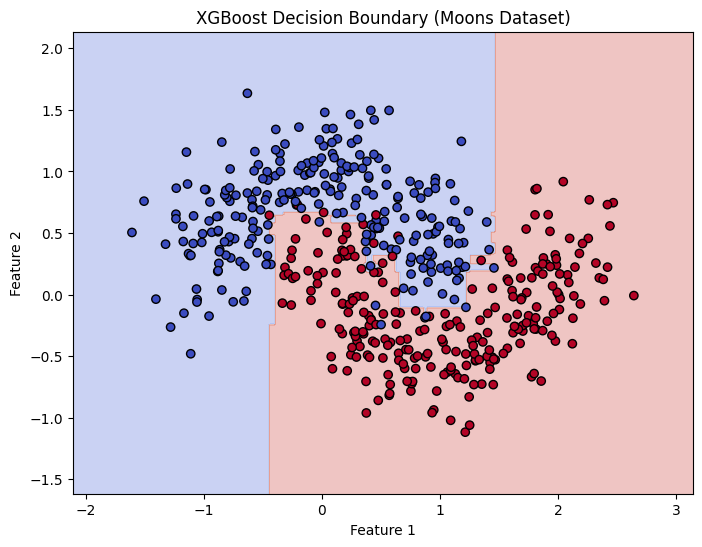

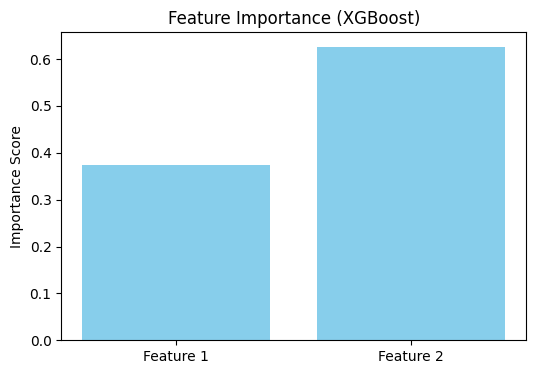

Feature 1: 0.3744
Feature 2: 0.6256


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import xgboost as xgb

# Generate moons dataset
X, y = make_moons(n_samples=500, noise=0.25, random_state=42)

# ---- Train XGBoost Classifier ----
xgb_clf = xgb.XGBClassifier(
    n_estimators=1000,    # number of boosting rounds (trees)
    max_depth=5,         # max depth of trees
    learning_rate=0.01,   # step size shrinkage
    subsample=1,       # row sampling
    colsample_bytree=1,# feature sampling
    eval_metric="logloss",
    random_state=42
)

xgb_clf.fit(X, y)

# ---- Plot decision boundary ----
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

Z = xgb_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolor="k")
plt.title("XGBoost Decision Boundary (Moons Dataset)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# ---- Feature Importance ----
importances = xgb_clf.feature_importances_
feature_names = ["Feature 1", "Feature 2"]

plt.figure(figsize=(6, 4))
plt.bar(feature_names, importances, color="skyblue")
plt.title("Feature Importance (XGBoost)")
plt.ylabel("Importance Score")
plt.show()

# Print feature ranking
for name, importance in zip(feature_names, importances):
    print(f"{name}: {importance:.4f}")

#**Homework**
**choose a a Dataset**:
* **MNIST** Handwritten Digit Dataset (you can load it using sklearn.datasets or tensorflow.keras.datasets or just use the provided csv files)

* **your own dataset** (anything related to your research). If you are using your own dataset, make sure that there are enough data and features. (at least 500 rows of data and 5 features) Also include enough background and details in your dataset.

The MNIST (Modified National Institute of Standards and Technology) dataset is one of the most famous benchmark datasets in machine learning. We will continue to experiment on this dataset in the future.
* It contains 70,000 grayscale images of handwritten digits (0 through 9).
* 60,000 images are for training and 10,000 for testing.
* Each image is 28 * 28 pixels so (784 features if fattened into a vector).
* Pixel values range from 0 (white) to 255 (black).
<br>

**Task**: Train and evaluate a random forest clasifier to recognize handwritten digits.

**Requirements**:
* Train a random forest classifier on the training set.
* Experiment with at least two different hyperparameter settings (e.g., n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features).
* Evaluate your model on both the training set and the test set. Your evaluation must include accuracy and confusion matrix. In addition, measure and report the training time for each experiment with different parameter settings (use time.time() function to record the duration).
* write a report for all the experiments you conducted, including different parameters you tested. Show the results and plots and discuss your findings.
(Optional) Visulaize feeature importance to show which pixels are most influential in the classification.(You may reshape the 784 pixels back to [28,28] array)

You are required to submit a report document (pdf) and a colab notebook file (.ipynb).<br><br>

Pre-Class Reading:

[Neural Network](https://www.geeksforgeeks.org/machine-learning/neural-networks-a-beginners-guide/)

In [1]:
#choose a a Dataset: MNIST
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Load MNIST data
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist.data, mnist.target

print("Shape of data:", X.shape)
print("Shape of target:", y.shape)
print("Number of classes:", len(np.unique(y)))

Shape of data: (70000, 784)
Shape of target: (70000,)
Number of classes: 10


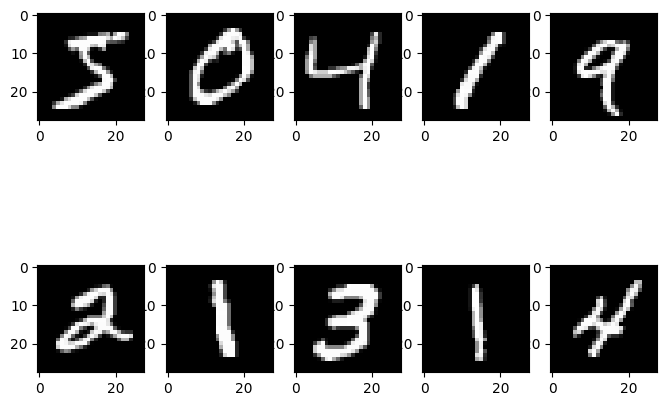

In [2]:
# Visualize dataset
plt.figure(figsize=(8, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i].reshape(28, 28), cmap='gray')



# Task
Train a random forest classifier on the MNIST dataset, experiment with at least two different hyperparameter settings, evaluate the models, and report the findings.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import time

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Experiment 1: Default hyperparameters
print("Experiment 1: Default Hyperparameters")
rf_clf_default = RandomForestClassifier(random_state=42)

start_time_default = time.time()
rf_clf_default.fit(X_train, y_train)
end_time_default = time.time()

print(f"Training time (default): {end_time_default - start_time_default:.2f} seconds")

# Experiment 2: Custom hyperparameters (e.g., n_estimators, max_depth)
print("\nExperiment 2: Custom Hyperparameters (n_estimators=200, max_depth=20)")
rf_clf_custom1 = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42)

start_time_custom1 = time.time()
rf_clf_custom1.fit(X_train, y_train)
end_time_custom1 = time.time()

print(f"Training time (custom 1): {end_time_custom1 - start_time_custom1:.2f} seconds")

# Experiment 3: Another set of custom hyperparameters
print("\nExperiment 3: Custom Hyperparameters (n_estimators=300, min_samples_split=10)")
rf_clf_custom2 = RandomForestClassifier(n_estimators=300, min_samples_split=10, random_state=42)

start_time_custom2 = time.time()
rf_clf_custom2.fit(X_train, y_train)
end_time_custom2 = time.time()

print(f"Training time (custom 2): {end_time_custom2 - start_time_custom2:.2f} seconds")

Experiment 1: Default Hyperparameters
Training time (default): 58.24 seconds

Experiment 2: Custom Hyperparameters (n_estimators=200, max_depth=20)
Training time (custom 1): 103.68 seconds

Experiment 3: Custom Hyperparameters (n_estimators=300, min_samples_split=10)
Training time (custom 2): 163.52 seconds


## Evaluate models

### Subtask:
Evaluate each trained Random Forest model on the training and test sets using accuracy and confusion matrix.


**Reasoning**:
Evaluate each trained Random Forest model on the training and test sets using accuracy and confusion matrix.




--- Evaluation for Default Hyperparameters ---
Training Accuracy (default): 1.0
Testing Accuracy (default): 0.9672857142857143
Classification Report (default):
               precision    recall  f1-score   support

           0       0.98      0.99      0.99      1343
           1       0.98      0.98      0.98      1600
           2       0.95      0.97      0.96      1380
           3       0.96      0.95      0.96      1433
           4       0.96      0.97      0.97      1295
           5       0.97      0.96      0.97      1273
           6       0.98      0.98      0.98      1396
           7       0.97      0.97      0.97      1503
           8       0.96      0.95      0.96      1357
           9       0.96      0.95      0.95      1420

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



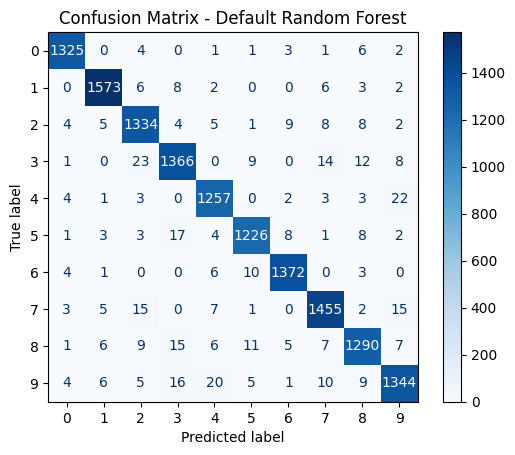


--- Evaluation for Custom Hyperparameters (n_estimators=200, max_depth=20) ---
Training Accuracy (custom 1): 0.9993571428571428
Testing Accuracy (custom 1): 0.968
Classification Report (custom 1):
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      1343
           1       0.98      0.99      0.98      1600
           2       0.95      0.97      0.96      1380
           3       0.97      0.95      0.96      1433
           4       0.97      0.97      0.97      1295
           5       0.97      0.96      0.97      1273
           6       0.98      0.98      0.98      1396
           7       0.97      0.97      0.97      1503
           8       0.95      0.95      0.95      1357
           9       0.95      0.95      0.95      1420

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



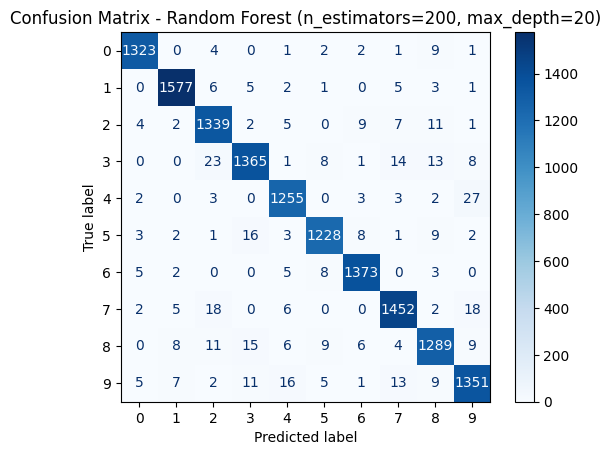


--- Evaluation for Custom Hyperparameters (n_estimators=300, min_samples_split=10) ---
Training Accuracy (custom 2): 0.9985
Testing Accuracy (custom 2): 0.9657142857142857
Classification Report (custom 2):
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1343
           1       0.99      0.98      0.98      1600
           2       0.95      0.97      0.96      1380
           3       0.96      0.95      0.95      1433
           4       0.96      0.97      0.96      1295
           5       0.97      0.96      0.97      1273
           6       0.98      0.98      0.98      1396
           7       0.97      0.96      0.97      1503
           8       0.95      0.95      0.95      1357
           9       0.95      0.95      0.95      1420

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



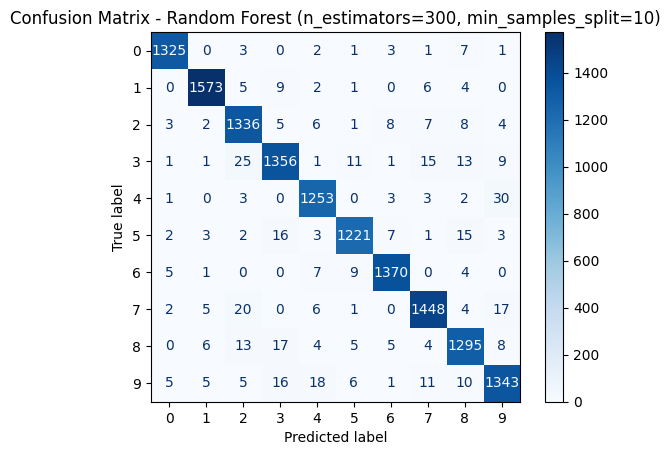

In [4]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Evaluate default model
print("\n--- Evaluation for Default Hyperparameters ---")
y_pred_train_default = rf_clf_default.predict(X_train)
y_pred_test_default = rf_clf_default.predict(X_test)

print("Training Accuracy (default):", accuracy_score(y_train, y_pred_train_default))
print("Testing Accuracy (default):", accuracy_score(y_test, y_pred_test_default))
print("Classification Report (default):\n", classification_report(y_test, y_pred_test_default))

cm_default = confusion_matrix(y_test, y_pred_test_default)
disp_default = ConfusionMatrixDisplay(confusion_matrix=cm_default, display_labels=np.unique(y))
disp_default.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Default Random Forest")
plt.show()

# Evaluate custom model 1
print("\n--- Evaluation for Custom Hyperparameters (n_estimators=200, max_depth=20) ---")
y_pred_train_custom1 = rf_clf_custom1.predict(X_train)
y_pred_test_custom1 = rf_clf_custom1.predict(X_test)

print("Training Accuracy (custom 1):", accuracy_score(y_train, y_pred_train_custom1))
print("Testing Accuracy (custom 1):", accuracy_score(y_test, y_pred_test_custom1))
print("Classification Report (custom 1):\n", classification_report(y_test, y_pred_test_custom1))

cm_custom1 = confusion_matrix(y_test, y_pred_test_custom1)
disp_custom1 = ConfusionMatrixDisplay(confusion_matrix=cm_custom1, display_labels=np.unique(y))
disp_custom1.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Random Forest (n_estimators=200, max_depth=20)")
plt.show()

# Evaluate custom model 2
print("\n--- Evaluation for Custom Hyperparameters (n_estimators=300, min_samples_split=10) ---")
y_pred_train_custom2 = rf_clf_custom2.predict(X_train)
y_pred_test_custom2 = rf_clf_custom2.predict(X_test)

print("Training Accuracy (custom 2):", accuracy_score(y_train, y_pred_train_custom2))
print("Testing Accuracy (custom 2):", accuracy_score(y_test, y_pred_test_custom2))
print("Classification Report (custom 2):\n", classification_report(y_test, y_pred_test_custom2))

cm_custom2 = confusion_matrix(y_test, y_pred_test_custom2)
disp_custom2 = ConfusionMatrixDisplay(confusion_matrix=cm_custom2, display_labels=np.unique(y))
disp_custom2.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Random Forest (n_estimators=300, min_samples_split=10)")
plt.show()